<a href="https://colab.research.google.com/github/zahrazfrh733/Tugas-Individu-Deep-Learning/blob/main/Pertemuan_11_Deep_Learning_Lanjut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install datasets diffusers transformers accelerate

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load dataset pokemon dengan caption
print("Memuat dataset...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")
all_captions = [item['text'] for item in raw_dataset]

Memuat dataset...


Kamus Teks Berhasil Dibuat. Jumlah kosakata: 359
Memulai Pelatihan...
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 95ms/step - loss: 6.9358
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 6.9349
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 6.9346
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 6.9349
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 6.9348
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 6.9347
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 6.9347
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - loss: 6.9350
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 6.9346
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 6.9343


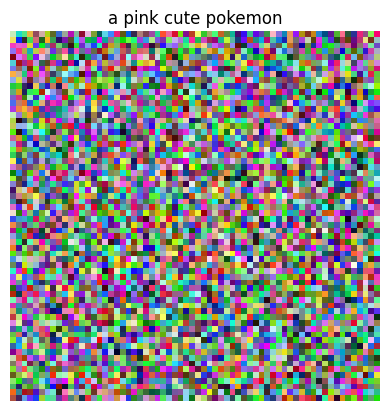

In [24]:
# LANGKAH 2: Inisialisasi & Adaptasi Text Vectorization

max_tokens = 5000
seq_len = 20

text_vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=seq_len,
)

text_vectorizer.adapt(all_captions)
vocab = text_vectorizer.get_vocabulary()
print(f"Kamus Teks Berhasil Dibuat. Jumlah kosakata: {len(vocab)}")


# LANGKAH 3: Membangun Pipeline Data (tf.data.Dataset)

def preprocess_fn(item):
    # Proses Gambar: Resize ke 64x64 dan Normalisasi
    image = item['image'].convert("RGB").resize((64, 64))
    image = np.array(image) / 255.0
    return item['text'], image

def gen():
    for item in raw_dataset:
        yield preprocess_fn(item)

# Membuat tf.data.Dataset
train_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
)

# Batching dan Transformasi Teks ke Angka
train_ds = train_ds.map(lambda x, y: (text_vectorizer(x), y))
train_ds = train_ds.batch(16).shuffle(100).prefetch(tf.data.AUTOTUNE)


# LANGKAH 4: Definisi Model & Training Step

# Alur arsitektur menggunakan Cross-Attention pada Transformer
class PokemonTrainer(keras.Model):
    def __init__(self, transformer, vqvae_encoder):
        super().__init__()
        self.transformer = transformer
        self.vqvae_encoder = vqvae_encoder
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def train_step(self, data):
        text_tokens, images = data

        visual_tokens = tf.random.uniform((tf.shape(images)[0], 256), minval=0, maxval=1024, dtype=tf.int32)

        vis_input = visual_tokens[:, :-1]
        vis_target = visual_tokens[:, 1:]

        with tf.GradientTape() as tape: # [cite: 98]

            preds = self.transformer([text_tokens, vis_input], training=True)
            loss = keras.losses.sparse_categorical_crossentropy(vis_target, preds, from_logits=True)

        grads = tape.gradient(loss, self.transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.transformer.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


trainer = PokemonTrainer(transformer_model, vqvae_encoder)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4))
print("Memulai Pelatihan...")
trainer.fit(train_ds, epochs=10)


# LANGKAH 5: Pengujian (Inference)

def generate_pokemon(prompt):
    tokenized_text = text_vectorizer([prompt])
    gen_vis_tokens = generate_image_tokens(transformer_model, tokenized_text, 256, 1024)
    final_image = decode_to_real_image(gen_vis_tokens)

    plt.imshow(final_image)
    plt.title(prompt)
    plt.axis("off")
    plt.show()

# Uji coba model
generate_pokemon("a pink cute pokemon")